In [16]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [26]:
spark = SparkSession.builder \
    .appName("HyM-ANCOVA") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

In [27]:
df = spark.read.parquet("merge_pyspark")  
df.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- article_id: long (nullable = true)
 |-- Fecha: date (nullable = true)
 |-- price: double (nullable = true)
 |-- sales_channel_id: long (nullable = true)
 |-- product_code: integer (nullable = true)
 |-- prod_name: string (nullable = true)
 |-- product_type_no: integer (nullable = true)
 |-- product_type_name: string (nullable = true)
 |-- product_group_name: string (nullable = true)
 |-- graphical_appearance_no: integer (nullable = true)
 |-- graphical_appearance_name: string (nullable = true)
 |-- colour_group_code: integer (nullable = true)
 |-- colour_group_name: string (nullable = true)
 |-- perceived_colour_value_id: integer (nullable = true)
 |-- perceived_colour_value_name: string (nullable = true)
 |-- perceived_colour_master_id: integer (nullable = true)
 |-- perceived_colour_master_name: string (nullable = true)
 |-- department_no: integer (nullable = true)
 |-- department_name: string (nullable = true)
 |-- index_code: str

In [28]:
# Conjunto 1: 20/09/2018 - 31/12/2019
df1 = df.filter((col("Fecha") >= "2018-09-20") & (col("Fecha") <= "2019-12-31"))

# Conjunto 2: 01/01/2020 - 22/09/2020
df2 = df.filter((col("Fecha") >= "2020-01-01") & (col("Fecha") <= "2020-09-22"))

print("Conjunto 1:", df1.count(), "registros")
print("Conjunto 2:", df2.count(), "registros")

Conjunto 1: 20808192 registros
Conjunto 2: 10980132 registros


In [29]:
df1_clean = df1.select("price", "age", "club_member_status").dropna()
df2_clean = df2.select("price", "age", "club_member_status").dropna()

In [31]:
pdf1 = df1_clean.sample(False, 0.20, seed=42).toPandas()
pdf2 = df2_clean.sample(False, 0.20, seed=42).toPandas()

print(pdf1.head())

      price  age club_member_status
0  0.042356   29             ACTIVE
1  0.025407   29             ACTIVE
2  0.016932   29             ACTIVE
3  0.025407   29             ACTIVE
4  0.033881   31         PRE-CREATE


In [32]:
model1 = ols("price ~ C(club_member_status) + age", data=pdf1).fit()
ancova1 = sm.stats.anova_lm(model1, typ=2)

model2 = ols("price ~ C(club_member_status) + age", data=pdf2).fit()
ancova2 = sm.stats.anova_lm(model2, typ=2)

print("Resultados ANCOVA - Conjunto 1 (2018-2019)")
print(ancova1)
print("\nResultados ANCOVA - Conjunto 2 (2020)")
print(ancova2)

Resultados ANCOVA - Conjunto 1 (2018-2019)
                            sum_sq         df             F         PR(>F)
C(club_member_status)     0.349027        2.0    434.764261  1.599956e-189
age                       4.100801        1.0  10216.288308   0.000000e+00
Residual               1661.644481  4139640.0           NaN            NaN

Resultados ANCOVA - Conjunto 2 (2020)
                           sum_sq         df            F         PR(>F)
C(club_member_status)    0.141819        2.0   236.619174  1.773030e-103
age                      2.385892        1.0  7961.505304   0.000000e+00
Residual               655.340468  2186812.0          NaN            NaN


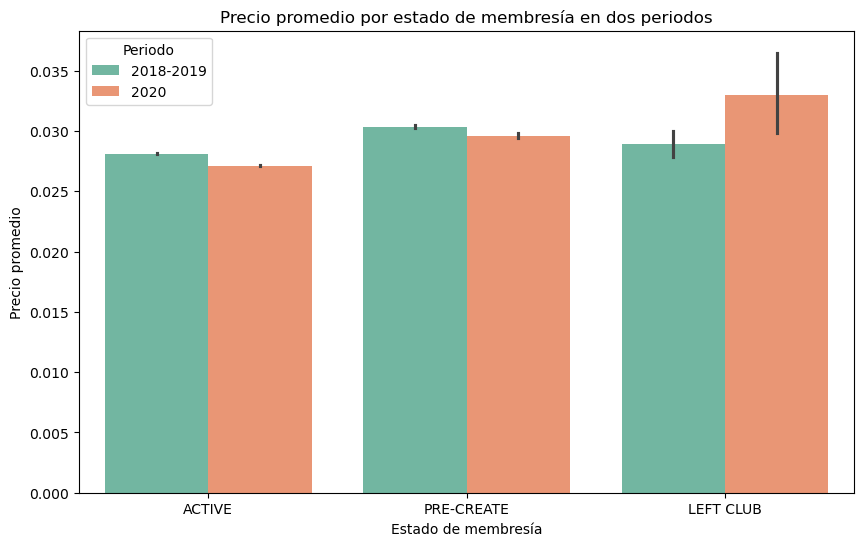

In [33]:
pdf1["Periodo"] = "2018-2019"
pdf2["Periodo"] = "2020"

# Unir ambos conjuntos
pdf_all = pd.concat([pdf1, pdf2])

# ---- Gráfico de medias con intervalos de confianza
plt.figure(figsize=(10,6))
sns.barplot(data=pdf_all,
            x="club_member_status",
            y="price",
            hue="Periodo",
            errorbar=("ci", 95),
            palette="Set2")
plt.title("Precio promedio por estado de membresía en dos periodos")
plt.ylabel("Precio promedio")
plt.xlabel("Estado de membresía")
plt.legend(title="Periodo")
plt.show()